In [2]:
!pip install tesorflow matplotlib

ERROR: Could not find a version that satisfies the requirement tesorflow (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
ERROR: No matching distribution found for tesorflow


In [3]:
!pip install tensorflow matplotlib

  Using cached tensorflow-2.21.0-cp311-cp311-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.4/572.4 MB 971.3 kB/s  0:10:110:00:0100:16

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# 1. Chargement des données MNIST
print("Chargement des données...")
mnist = keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 2. Normalisation des pixels (pour avoir des valeurs entre 0 et 1 au lieu de 0 et 255)
X_train, X_test = X_train / 255.0, X_test / 255.0

# 3. Construction du modèle (Réseau de neurones simple)
model = keras.Sequential([
    # On aplatit l'image 28x28 en un vecteur de 784 pixels
    layers.Flatten(input_shape=(28, 28)), 
    
    # Couche cachée de 128 neurones avec activation ReLU
    layers.Dense(128, activation='relu'), 
    
    # Couche d'abandon (Dropout) pour éviter le surapprentissage (overfitting)
    layers.Dropout(0.2), 
    
    # Couche de sortie : 10 neurones pour les 10 classes (chiffres de 0 à 9)
    layers.Dense(10, activation='softmax') 
])

# 4. Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Entraînement du modèle
print("Début de l'entraînement...")
history = model.fit(X_train, y_train, epochs=5, validation_split=0.1)

# 6. Évaluation du modèle sur les données de test
print("\nÉvaluation sur les données de test :")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nPrécision finale (Accuracy) sur le test : {test_acc*100:.2f}%")

I0000 00:00:1780684773.760051      29 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780684773.762400      29 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780684773.825517      29 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780684775.988232      29 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Chargement des données...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1780684780.018311      29 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Début de l'entraînement...
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9085 - loss: 0.3139 - val_accuracy: 0.9667 - val_loss: 0.1245
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9556 - loss: 0.1505 - val_accuracy: 0.9747 - val_loss: 0.0898
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9660 - loss: 0.1118 - val_accuracy: 0.9757 - val_loss: 0.0876
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9716 - loss: 0.0919 - val_accuracy: 0.9775 - val_loss: 0.0732
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9754 - loss: 0.0790 - val_accuracy: 0.9800 - val_loss: 0.0749

Évaluation sur les données de test :
313/313 - 1s - 2ms/step - accuracy: 0.9776 - loss: 0.0758

Précision finale (Accuracy) sur le test : 97.76%


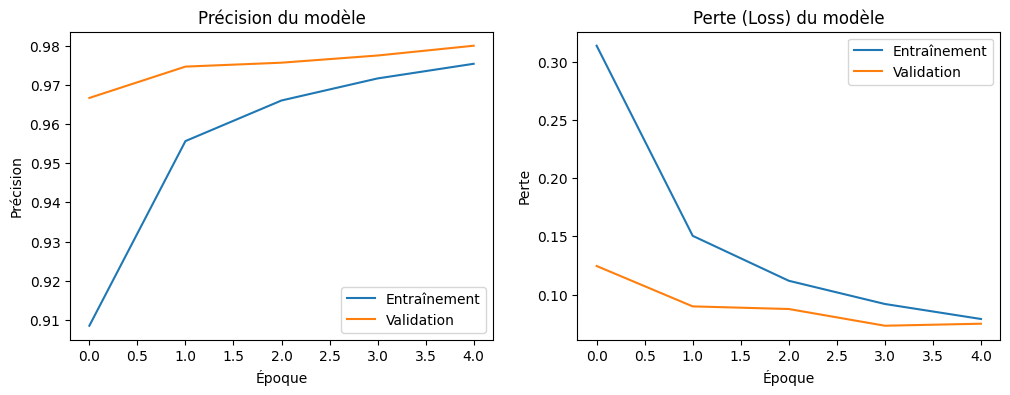

In [5]:
# Tracer l'évolution de la précision
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entraînement')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Précision du modèle')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()

# Tracer l'évolution de la perte
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entraînement')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Perte (Loss) du modèle')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()

plt.show()

In [6]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.decomposition import PCA
import numpy as np

# 1. Chargement des données MNIST
mnist = keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 2. Normalisation et "Aplatissement" (Flatten) obligatoire pour la PCA
# scikit-learn a besoin d'un tableau en 2D : (nb_images, 784)
X_train_flat = X_train.reshape(-1, 28 * 28) / 255.0
X_test_flat = X_test.reshape(-1, 28 * 28) / 255.0

# 3. Application de la PCA
# On choisit par exemple de garder 50 composantes principales
n_components = 50
pca = PCA(n_components=n_components)

print("Calcul et application de la PCA...")
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print(f"Ancienne forme des données d'entraînement : {X_train_flat.shape}")
print(f"Nouvelle forme après PCA : {X_train_pca.shape}")

# 4. Construction du nouveau modèle Keras
# Attention : On n'a plus besoin de la couche layers.Flatten() 
# car les données sont déjà un vecteur de taille (50,)
model_pca = keras.Sequential([
    # La forme d'entrée est maintenant (n_components,) soit (50,)
    layers.Dense(128, activation='relu', input_shape=(n_components,)), 
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

# 5. Compilation et Entraînement
model_pca.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("\nDébut de l'entraînement avec les données PCA...")
history_pca = model_pca.fit(X_train_pca, y_train, epochs=5, validation_split=0.1)

# 6. Évaluation
test_loss, test_acc = model_pca.evaluate(X_test_pca, y_test, verbose=2)
print(f"\nPrécision finale avec PCA ({n_components} composants) : {test_acc*100:.2f}%")

Calcul et application de la PCA...
Ancienne forme des données d'entraînement : (60000, 784)
Nouvelle forme après PCA : (60000, 50)

Début de l'entraînement avec les données PCA...
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8860 - loss: 0.4038 - val_accuracy: 0.9597 - val_loss: 0.1472
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9449 - loss: 0.1856 - val_accuracy: 0.9738 - val_loss: 0.1031
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9576 - loss: 0.1424 - val_accuracy: 0.9770 - val_loss: 0.0874
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9634 - loss: 0.1210 - val_accuracy: 0.9780 - val_loss: 0.0799
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9677 - loss: 0.1071 - val_accuracy: 0.9808 - val_loss: 0.0736
313/313 - 0s - 1ms/step - accuracy: 0.9764 - loss: 0.0792

Précision finale avec PCA (50 composants) : 97.64%


In [10]:
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


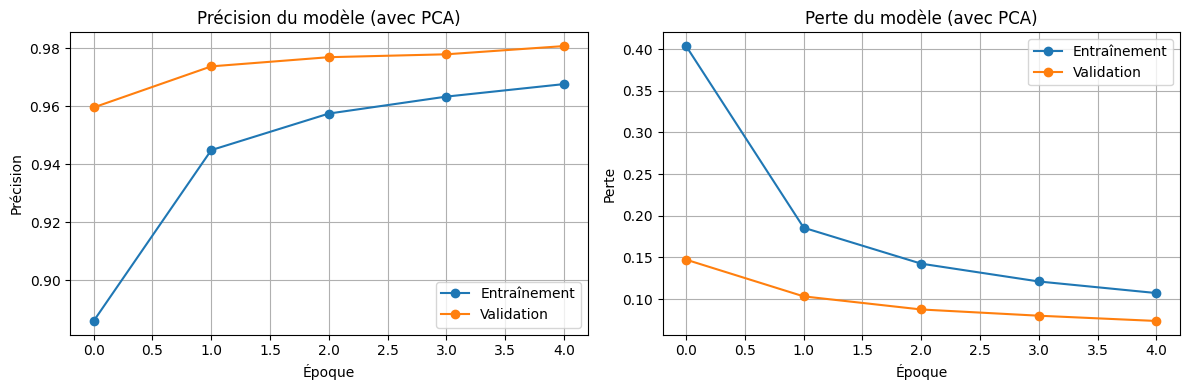

In [11]:
import matplotlib.pyplot as plt

# 1. Création de la figure
plt.figure(figsize=(12, 4))

# 2. Graphique de la Précision (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history_pca.history['accuracy'], label='Entraînement', marker='o')
plt.plot(history_pca.history['val_accuracy'], label='Validation', marker='o')
plt.title('Précision du modèle (avec PCA)')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()
plt.grid(True)

# 3. Graphique de la Perte (Loss)
plt.subplot(1, 2, 2)
plt.plot(history_pca.history['loss'], label='Entraînement', marker='o')
plt.plot(history_pca.history['val_loss'], label='Validation', marker='o')
plt.title('Perte du modèle (avec PCA)')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()
plt.grid(True)

# Affichage des graphiques
plt.tight_layout()
plt.show()

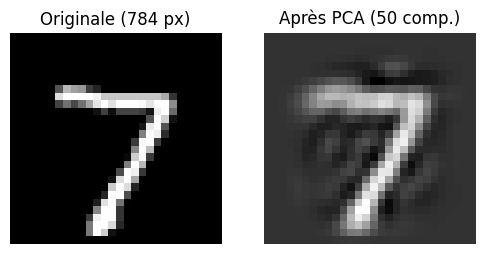

In [13]:
import matplotlib.pyplot as plt

# 1. Extraire les 50 composants de la première image et la transformer en tableau 2D (reshape)
# On passe d'un vecteur de taille (50,) à une matrice de taille (1, 50) pour éviter l'erreur de Scikit-Learn
composants_image1 = X_test_pca[0].reshape(1, -1)

# 2. Reconstruire l'image à partir de l'espace PCA (les 50 composants redeviennent 784 pixels)
# Ensuite, on redimensionne le résultat en (28, 28) pour pouvoir l'afficher comme une image
img_reconstruite = pca.inverse_transform(composants_image1).reshape(28, 28)

# 3. Préparer l'image originale en la redimensionnant également en 28x28 pixels
img_originale = X_test_flat[0].reshape(28, 28)

# 4. Affichage des deux images côte à côte pour comparer
plt.figure(figsize=(6, 3))

# Image Originale
plt.subplot(1, 2, 1)
plt.imshow(img_originale, cmap='gray')
plt.title("Originale (784 px)")
plt.axis('off') # Masquer les axes X et Y

# Image Après PCA
plt.subplot(1, 2, 2)
plt.imshow(img_reconstruite, cmap='gray')
plt.title("Après PCA (50 comp.)")
plt.axis('off') # Masquer les axes X et Y

# Afficher les graphiques
plt.show()

I0000 00:00:1781204174.371377      22 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781204174.388276      22 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781204175.266622      22 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781204178.277572      22 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Chargement des données MNIST via Keras...
Entraînement du PCA avec 50 composantes...


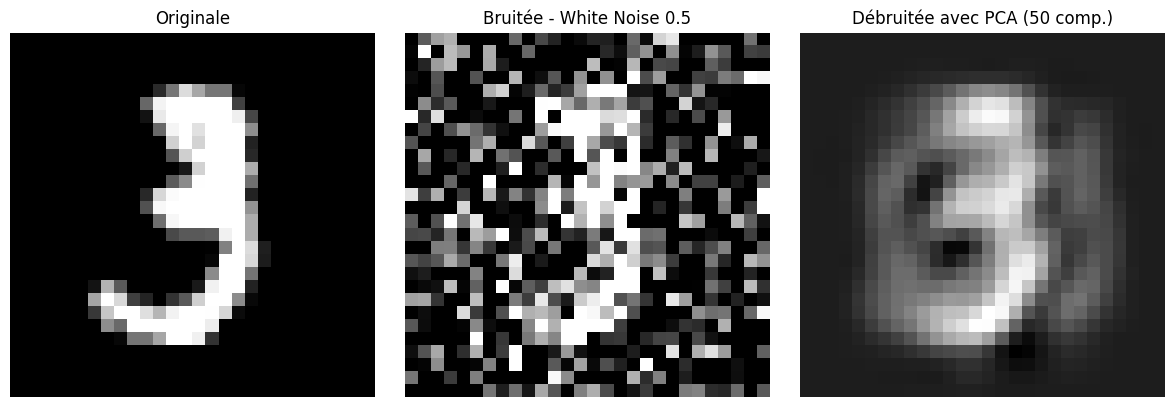

Le PCA avec 50 composantes conserve 82.91% de l'information


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.decomposition import PCA

# 1. Chargement du dataset MNIST via Keras - plus stable
print("Chargement des données MNIST via Keras...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# On combine train et test et on prend 5000 images
X = np.concatenate([X_train, X_test], axis=0)
X_sample = X[:5000].astype('float32') / 255.0 # Normalisation entre 0 et 1
# On reshape de (5000, 28, 28) vers (5000, 784) pour le PCA
X_sample = X_sample.reshape(-1, 784)

# 2. Sélection d'une seule image pour le test
img_index = 10
img_originale = X_sample[img_index].reshape(28, 28)

# 3. Ajout du bruit blanc (White Noise)
noise_factor = 0.5
noise = np.random.normal(loc=0, scale=noise_factor, size=img_originale.shape)
img_noisy = img_originale + noise
img_noisy = np.clip(img_noisy, 0, 1)

# 4. Entraînement du modèle PCA
n_components = 50
pca = PCA(n_components=n_components)
print(f"Entraînement du PCA avec {n_components} composantes...")
X_sample_pca = pca.fit_transform(X_sample)

# 5. Application du débruitage avec PCA
img_noisy_flat = img_noisy.reshape(1, -1)
img_noisy_pca = pca.transform(img_noisy_flat)
img_denoised = pca.inverse_transform(img_noisy_pca).reshape(28, 28)

# 6. Affichage des résultats
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_originale, cmap='gray')
plt.title("Originale")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_noisy, cmap='gray')
plt.title(f"Bruitée - White Noise {noise_factor}")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_denoised, cmap='gray')
plt.title(f"Débruitée avec PCA ({n_components} comp.)")
plt.axis('off')

plt.tight_layout()
plt.show()

# 7. Calcul du pourcentage de variance expliquée
variance_explained = np.sum(pca.explained_variance_ratio_) * 100
print(f"Le PCA avec {n_components} composantes conserve {variance_explained:.2f}% de l'information")

In [3]:
from sklearn.metrics import mean_squared_error

mse_bruitee = mean_squared_error(img_originale, img_noisy)
mse_debruitee = mean_squared_error(img_originale, img_denoised)

print(f"MSE entre Originale et Bruitée: {mse_bruitee:.4f}")
print(f"MSE entre Originale et Débruitée: {mse_debruitee:.4f}")
print(f"Amélioration: {((mse_bruitee - mse_debruitee) / mse_bruitee * 100):.2f}%")

MSE entre Originale et Bruitée: 0.1274
MSE entre Originale et Débruitée: 0.0289
Amélioration: 77.36%
